# ECE236A (Fall 2025)

This notebook shows **how to use** the provided `utils.py` and your `MySolution_{group_number}.py` for:
- **Task 1** (baseline classifier),
- **Task 2** (centralized compression),
- **Task 3.1** (per-sensor budget), **Task 3.2** (total budget), and
- **Task 3.3** (minimal bits for target accuracy).

It includes **commented-out** code blocks that you can enable after you implement your methods.
For now, we also include **mock results** to show the required plotting formats.

> **Important:** These cells are **guidelines**, not a complete solution. You may (and often should) adapt the code to:
> - output all required artifacts for the report (e.g., chosen allocations, validation choices, baselines),
> - plot additional figures that strengthen your analysis,
> - add helper functions/visualizations to support your arguments.
>
> This boilerplate demonstrates how to **wire up** the methods and plotting utilities. You’re responsible for producing all figures/results requested in the project handout.

In [15]:
from utils import *
from MySolution_2 import MyDecentralized, MyFeatureCompression, MyTargetAllocator
import scipy 
import matplotlib.pyplot as plt 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load datasets

Synthetic shapes: (800, 2) (800,)


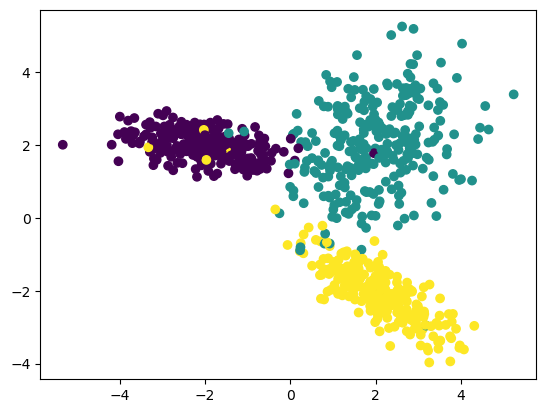

In [16]:
syn_data = prepare_synthetic_data()
print("Synthetic shapes:", syn_data['trainX'].shape, syn_data['trainY'].shape)
plt.scatter(syn_data['trainX'][:, 0], syn_data['trainX'][:, 1], c=syn_data['trainY']); plt.show()

MNIST shapes: (800, 784) (800,)


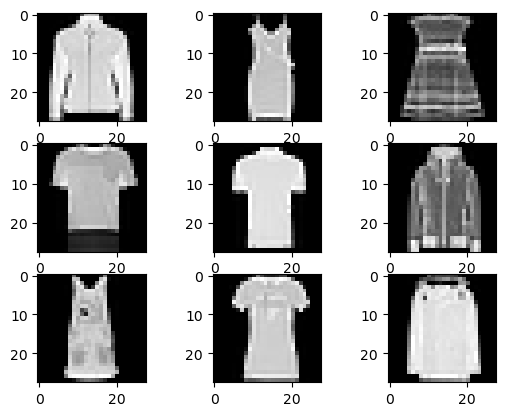

In [17]:
mnist_data = prepare_mnist_data()
print("MNIST shapes:", mnist_data['trainX'].shape, mnist_data['trainY'].shape)
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(mnist_data['trainX'][i].reshape(28,28), cmap='gray')
plt.show()

## Task 1 — Baseline classifier (Decentralized class, no compression)
Uncomment the following once you've implemented `MyDecentralized.train/predict/score`.

In [18]:
clf = MyDecentralized(K=3)
clf.train(syn_data['trainX'], syn_data['trainY'])  # if you need val, modify signature accordingly
syn_test_acc = clf.evaluate(syn_data['testX'], syn_data['testY'])
print("Task 1 test accuracy:", syn_test_acc)

clf = MyDecentralized(K=3)
clf.train(mnist_data['trainX'], mnist_data['trainY'])  # if you need val, modify signature accordingly
mnist_test_acc = clf.evaluate(mnist_data['testX'], mnist_data['testY'])
print("Task 1 test accuracy:", mnist_test_acc)

Task 1 test accuracy: 0.97
Task 1 test accuracy: 0.908


Text(0, 0.5, '% Accuracy')

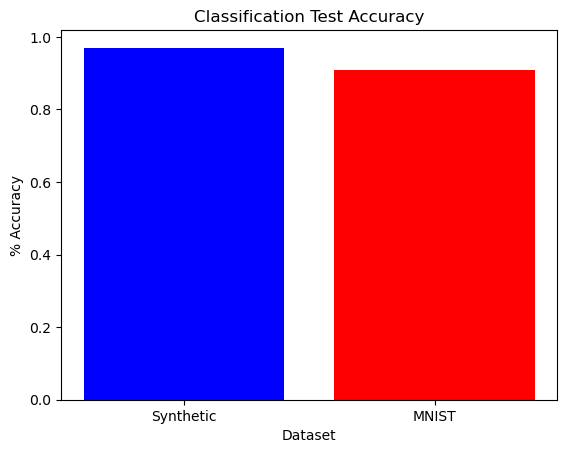

In [19]:
plt.bar(['Synthetic', 'MNIST'], [syn_test_acc, mnist_test_acc], color = [ 'blue','red'])
plt.title("Classification Test Accuracy")
plt.xlabel("Dataset")
plt.ylabel("% Accuracy")

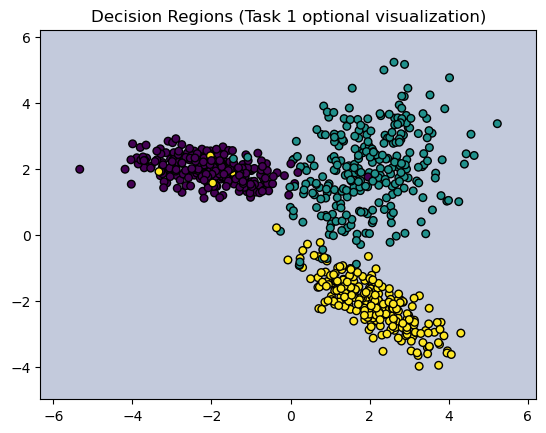

In [20]:
visualize_2d_decision_boundary(clf, syn_data['trainX'], syn_data['trainY'])
plt.show()

### Notes on bit budgets

- **Uniform Scalar Quantization (USQ):**  
  The simplest baseline scheme is to quantize each feature (e.g., image pixel) independently using the same number of bits `b`.  
  The total budget is then `B_tot = M * b` with `M = 784` (28×28).  
  Example: `B_TOT_LIST = [784, 1568, 2352]` corresponds to **1 / 2 / 3 bits per feature** under USQ.  
  However, you can assign different bit-depths to different features, which would allow you to reach even lower budgets (e.g., `b=0` for some features).

- **Other quantizers:**  
  If you use non-uniform scalar, companded, or vector quantization, this direct formula may not apply.  
  In those cases, interpret `B_tot` as your **total bits per image** based on your quantizer design  
  (e.g., sum of bits for transmitted indices, parameters, or blocks).  
  - **If you transmit selectively (e.g., only send clustered or informative samples):**  
  Report your budget as the **average total bits per image across the full dataset**,  
  not just the bits for transmitted samples. This ensures fair comparison with methods  
  that send every image.

  Be explicit in your report about how you compute and compare bit budgets.

- **Decentralized setting:**  
  Each sensor has `d_s = 196` features; a per-sensor budget `k` corresponds to a local bit constraint.  
  In USQ, this implies a local bit-depth `b_s ≈ floor(k / d_s)`;  
  in more general designs, `k` is simply the total bits that sensor `s` is allowed to send per image.

- **No-quantization reference:**  
  Original (uncompressed) features are the upper bound.  
  For an 8-bit scalar baseline: `784 * 8 = 6272` bits/image.

- **Compare apples-to-apples:**  
  Use the same total budgets (`B_TOT_LIST`) across centralized and decentralized experiments,  
  but remember that the mapping between bits and quantization precision may differ depending on your quantizer.

## Task 2 — Centralized compression
Uncomment the following once you've implemented `MyFeatureCompression.run_centralized`.

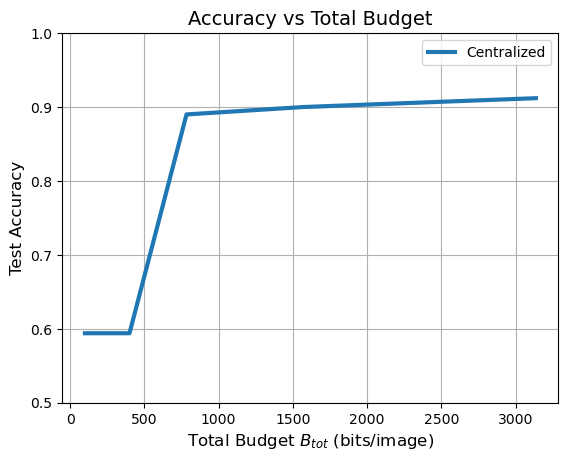

In [21]:
fc = MyFeatureCompression(K=3)
B_tot_list = [100, 400, 784, 1568, 2352, 3136]  # example budgets (you can modify)
res_central = fc.run_centralized(
    mnist_data['trainX'], mnist_data['trainY'],
    mnist_data['valX'],   mnist_data['valY'],
    mnist_data['testX'],  mnist_data['testY'],
    B_tot_list=B_tot_list,
)
plot_result_total(result2=res_central, result3_2=None)

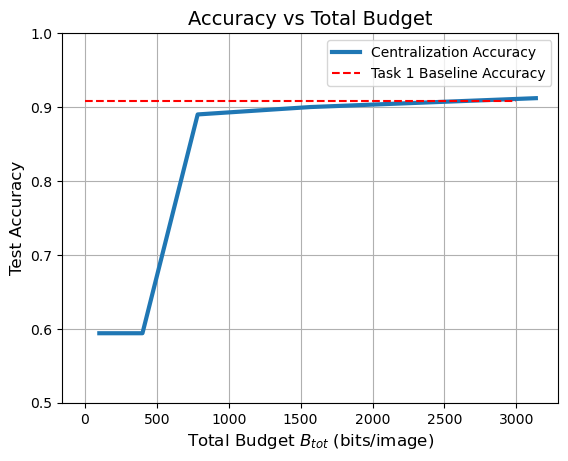

In [22]:
# above plot w/overlaid Task 1 Baseline Accuracy
result2=res_central
plt.plot(result2['B_tot'], result2['test_accuracy'], label='Centralization Accuracy', markersize=12, linewidth=3)
x = np.linspace(0,3000)
plt.plot(x, np.ones(50)*mnist_test_acc, 'r--', label = "Task 1 Baseline Accuracy")
plt.legend()
plt.ylim(0.5, 1)
plt.xlabel("Total Budget $B_{tot}$ (bits/image)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Accuracy vs Total Budget", fontsize=14)
plt.grid(True)
plt.show()

## Task 3.1 — Decentralized: fixed per-sensor budget
Uncomment the following once you've implemented `MyFeatureCompression.run_decentralized_per_sensor`.

In [23]:
I_train, Xtr_blocks = split_into_quadrants(mnist_data['trainX'])
_,       Xva_blocks = split_into_quadrants(mnist_data['valX'])
_,       Xte_blocks = split_into_quadrants(mnist_data['testX'])

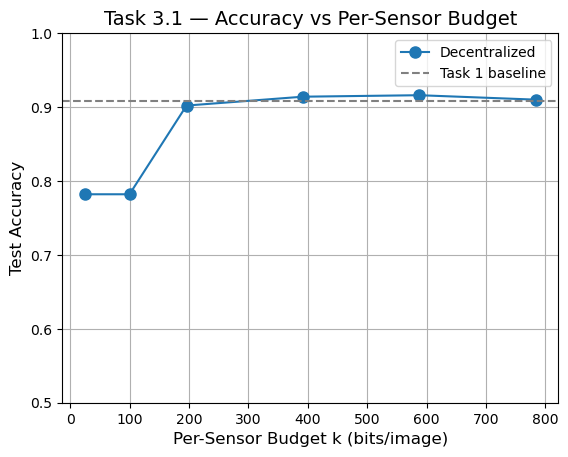

In [24]:
I_train, Xtr_blocks = split_into_quadrants(mnist_data['trainX'])
_,       Xva_blocks = split_into_quadrants(mnist_data['valX'])
_,       Xte_blocks = split_into_quadrants(mnist_data['testX'])

k_list = [25, 100, 196, 392, 588, 784] # example budgets (you can modify)
res_k = fc.run_decentralized_per_sensor(
    Xtr_blocks, Xva_blocks, Xte_blocks,
    mnist_data['trainY'], mnist_data['valY'], mnist_data['testY'],
    k_list=k_list,
)
res_k['baseline_test_accuracy_task1'] = mnist_test_acc
plot_result_per_sensor(result3_1=res_k)

## Task 3.2 — Decentralized: total bit budget
Uncomment the following once you've implemented `MyFeatureCompression.run_decentralized_total`.

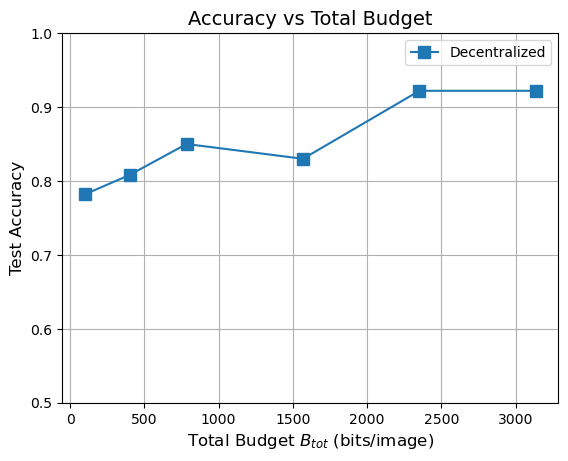

In [25]:
B_tot_list = [100, 400, 784, 1568, 2352, 3136]  # example budgets (you can modify)
res_B = fc.run_decentralized_total(
    Xtr_blocks, Xva_blocks, Xte_blocks,
    mnist_data['trainY'], mnist_data['valY'], mnist_data['testY'],
    B_tot_list=B_tot_list,
)
plot_result_total(result2=None, result3_2=res_B)

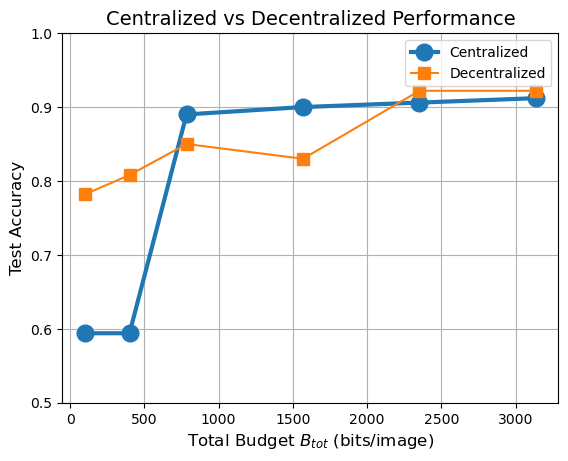

In [27]:
# overlay centralized vs decentralized
res_compare = {
    'centralized':   res_central,
    'decentralized': res_B,
}
plot_result_centralized_vs_decentralized(result=res_compare)

## Task 3.3 — Minimal bits for target accuracy
Uncomment once you've implemented `MyTargetAllocator` methods.

a:
0.6
min bits centralized
min bits decentralized
a:
0.7
min bits centralized
min bits decentralized
a:
0.8
min bits centralized
min bits decentralized
a:
0.9
min bits centralized
min bits decentralized


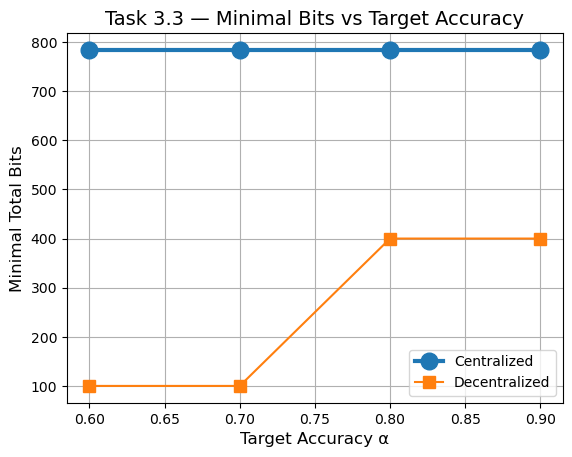

In [29]:
ta = MyTargetAllocator(K=3)
alphas = [0.6, 0.7, 0.8, 0.9]  # or choose based on your curves
B_grid = [100, 400, 784] #1568, 2352, 3136]  # example budgets (you can modify)
cent_min = []
decz_min = []
for a in alphas:
    print('a:')
    print(a)
    Bc = ta.minimal_bits_centralized(fc, mnist_data['trainX'], mnist_data['trainY'],
                                     mnist_data['valX'],   mnist_data['valY'],
                                     mnist_data['testX'],  mnist_data['testY'],
                                     alpha=a, B_grid=B_grid)
    Bd, alloc = ta.minimal_bits_decentralized(fc, Xtr_blocks, Xva_blocks, Xte_blocks,
                                              mnist_data['trainY'], mnist_data['valY'], mnist_data['testY'],
                                              alpha=a, B_grid=B_grid)
    cent_min.append(Bc)
    decz_min.append(Bd)
res_target = {'alphas': alphas, 'centralized_min_bits': cent_min, 'decentralized_min_bits': decz_min}
plot_result_target(result=res_target)